# InferCNV on BMMC NDMM Labeled Data

## 2025-01-22
### Palak Genge, High Resolution Translational Immunology, Allen Institute for Immunology
#### Objective: Run the package infercnvpy on a Scanpy .h5ad filtered plasma cell object run copy number variation analysis

### Load Required Packages and Define Functions

In [1]:
# Load required packages
import scanpy as sc
import infercnvpy as cnv
import matplotlib.pyplot as plt
import warnings
import biomart
import numpy as np
import anndata as ad
from pybiomart import Server
import time
from biomart import BiomartServer
import seaborn as sns
import glob
import os
import pandas as pd
import scipy
import hisepy as hp
import scanpy.external as sce
from IPython.display import display, HTML

In [3]:
# set working directory
os.chdir('../../../data/rna/infercnv/')
print("Current working directory:", os.getcwd())

Current working directory: /home/workspace/cnv_analyses_reharmonized


In [7]:
# Define function to grab chromosome positions for genes in preparation for inferCNV (AC)
# Modified slightly from AC version include checking other databases in case of connection error (PG)
from pybiomart import Server

def infercnv_adata_prep(adata, species="hsapiens", host='http://grch37.ensembl.org'):
    '''
    Simple function that works on any anndata object that has a .var where the index is a list of genes in HGNC-approved nomenclature format.
    '''
    print("Input data shape:", adata.shape)
    print("Input number of genes:", adata.n_vars)
    
    try:
        # Fetch annotations from BioMart
        annotations = sc.queries.biomart_annotations(
            species,
            ["ensembl_gene_id", "hgnc_symbol", "chromosome_name", "start_position", "end_position"],
            host=host
        )
    except KeyError as e:
        print(f"Error fetching annotations: {e}")
        print("Please check the BioMart server or try a different host.")
        return adata

    adata.var['hgnc_symbol'] = adata.var.index

    # Merge annotations with adata.var
    merged_data = adata.var.merge(annotations, on='hgnc_symbol', how='left')
    merged_data['chr_annotations'] = ~merged_data['ensembl_gene_id'].isna()
    merged_data = merged_data.drop_duplicates(subset=['hgnc_symbol']).set_index('hgnc_symbol')
    merged_data.index.name = None

    # Rename columns
    merged_data = merged_data.rename(columns={
        'ensembl_gene_id': 'ensg',
        'chromosome_name': 'chromosome',
        'start_position': 'start',
        'end_position': 'end'
    })

    # Add 'chr' prefix to chromosome names
    merged_data['chromosome'] = ['chr' + str(i) for i in merged_data['chromosome']]
    valid_chromosomes = {f'chr{i}' for i in range(1, 24)}.union({'chrX', 'chrY'})
    merged_data['valid_chromosome'] = merged_data['chromosome'].isin(valid_chromosomes)

    # Update adata.var with merged data
    adata.var = merged_data

    # Filter adata based on valid chromosomes and annotations
    adata = adata[:, adata.var_names[adata.var['chr_annotations'] & adata.var['valid_chromosome']]].copy()
   
    print("Data shape after removing genes that did not map:", adata.shape)
    print("Output number of genes:", adata.n_vars)
    
    return adata

In [20]:
# Define function to process single cell data object using scanpy built-in functions
def process_adata(adata, 
                  subset_hvgs=False, 
                  run_harmony=False, 
                  harmony_key=["data_source"], 
                  resolution=1.0, 
                  run_rank_genes=False):
    
    if adata.raw is None:
        print("No adata.raw found. Please ensure raw data exists before processing.")
        return None

    # Extract raw and re-assign
    adata = adata.raw.to_adata()
    adata.raw = adata

    # mitochondrial genes
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    # ribosomal genes
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    # hemoglobin genes
    adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
    )

    # Normalize and log1p
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    # HVG selection
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)
    # Optional: Subset to HVGs
    if subset_hvgs:
        adata = adata[:, adata.var['highly_variable']].copy()

    # Scale and PCA
    sc.pp.scale(adata, max_value=10, zero_center=False)
    sc.tl.pca(adata, svd_solver="arpack")
    adata.obsm["X_pca_temp"] = adata.obsm["X_pca"]

    # Optional: Harmonize on a metadata parameter
    if run_harmony:
        sce.pp.harmony_integrate(adata, key=harmony_key)
        adata.obsm["X_pca"] = adata.obsm["X_pca_harmony"]

    # Neighbors and dimensionality reduction
    sc.pp.neighbors(adata, n_neighbors=50, use_rep="X_pca", n_pcs=20)
    sc.tl.tsne(adata, n_pcs=20)
    sc.tl.umap(adata, min_dist=0.45, random_state=0, n_components=2)
    sc.tl.leiden(adata, resolution=resolution, flavor="igraph", n_iterations=2)

    # Optional: Rank genes (leiden)
    if run_rank_genes:
        sc.tl.rank_genes_groups(
            adata, groupby="leiden", method="t-test", corr_method="benjamini-hochberg"
        )

    return adata

### Read and Inspect Data

In [3]:
# download processed BMMC plasma subset files from allenimmunology.org
hp.cache_files(["697722a7-35cc-4f11-8265-ecccc93358be"])

['/home/workspace/input/849499887/FH_MM_Year4/697722a7-35cc-4f11-8265-ecccc93358be/dhBEZegaUf/bmmc-plasma-processed.h5ad']

In [8]:
# read in anndata object
plasma = sc.read_h5ad('../../../data/rna/bmmc-plasma-processed.h5ad')

In [27]:
# view data layers
plasma

AnnData object with n_obs × n_vars = 58023 × 33538
    obs: 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'ext_l1', 'ext_l2', 'ext_l3', 'healthy_l1', 'healthy_l2', 'healthy_l3', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'specimen.specimenGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'tissue', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.batch_id', 'manual.category', 'manual.treatment_dara', 'manual.flu_response', '

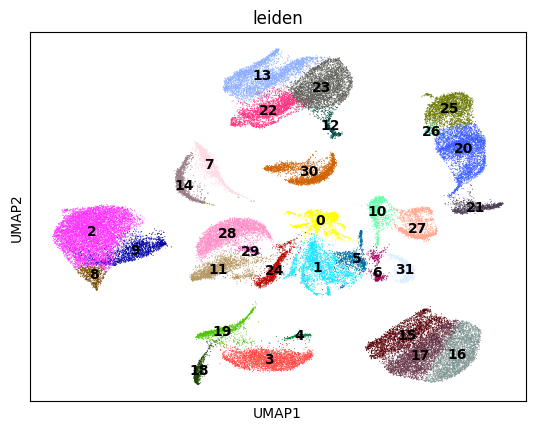

In [28]:
# inspect leiden clustering
sc.pl.umap(plasma, color = "leiden", legend_loc="on data")

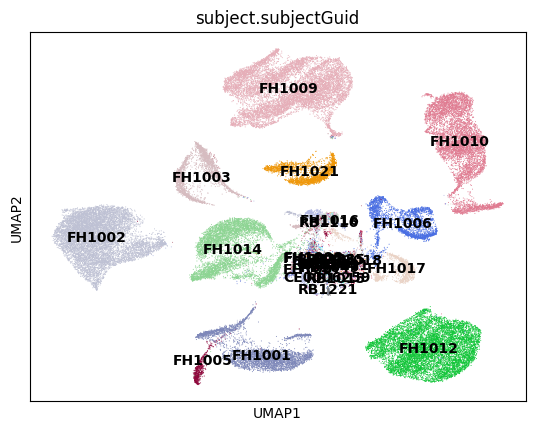

In [29]:
# inspect clustering by subject
sc.pl.umap(plasma, color = "subject.subjectGuid", legend_loc="on data")

### Prepare Data

##### High Level Steps
- Add in metadata and tumor state labels as identified by Melinda Angus-Hill and Aishwarya Chander
- Filter MM Pre-Treatment plasma cells based on available metadata
- Add back in internal healthy bone marrow controls from original object
- Add in external healthy bone marrow plasma cells

In [46]:
# read labeling metadata that AC and MAH created for the pretx tumor state defined labels
cluster_df = pd.read_parquet("../../../data/rna/infercnv/metadata/plasma_pretx_state_annotation.parquet")
cluster_df.head()

,plasma_annotation_leiden,plasma_labels_l3
barcodes,,
1d4b50cae88711eca2fc4e28d07d5108,0,MS-OxPhos
1d562388e88711eca2fc4e28d07d5108,0,MS-OxPhos
1d5c134ce88711eca2fc4e28d07d5108,7,Myeloid-Evasive
1d5d79e4e88711eca2fc4e28d07d5108,3,CD2-ISG+
1d63d1fee88711eca2fc4e28d07d5108,7,Myeloid-Evasive


In [47]:
# filter plasma object to only include cells present in metadata file (cluster_df)
plasma = plasma[plasma.obs_names.isin(cluster_df.index)].copy()

# add cluster annotation to each cell
plasma.obs['plasma_labels_l3'] = plasma.obs_names.map(cluster_df['plasma_labels_l3'])

In [51]:
# see total cell number by visit and ensure only MM Pre-Treatment remains
plasma.obs['sample.visitDetails']

barcodes
1d4b50cae88711eca2fc4e28d07d5108    MM Pre-Treatment
1d562388e88711eca2fc4e28d07d5108    MM Pre-Treatment
1d5c134ce88711eca2fc4e28d07d5108    MM Pre-Treatment
1d5d79e4e88711eca2fc4e28d07d5108    MM Pre-Treatment
1d63d1fee88711eca2fc4e28d07d5108    MM Pre-Treatment
                                          ...       
06784978e8a711ec9cc02a56aa421d9a    MM Pre-Treatment
06785e54e8a711ec9cc02a56aa421d9a    MM Pre-Treatment
0678d9d8e8a711ec9cc02a56aa421d9a    MM Pre-Treatment
067a0a4ce8a711ec9cc02a56aa421d9a    MM Pre-Treatment
067a1b40e8a711ec9cc02a56aa421d9a    MM Pre-Treatment
Name: sample.visitDetails, Length: 53946, dtype: category
Categories (1, object): ['MM Pre-Treatment']

In [54]:
# read in original object
all_plasma = sc.read_h5ad('../../../data/rna/bmmc-plasma-processed.h5ad')

In [58]:
# extract all healthy plasma samples
healthy_plasma = all_plasma[all_plasma.obs['sample.visitDetails'] == 'Healthy', :]

In [60]:
# merge the healthy back into the filtered plasma object and and tag as healthy_plasma in tumor state column
healthy_plasma.obs['plasma_labels_l3'] = "healthy_plasma"

# Concatenate the two AnnData objects
plasma = plasma.concatenate(healthy_plasma, join='outer', index_unique=None)

/tmp/ipykernel_5196/4092583800.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  healthy_plasma.obs['plasma_labels_l3'] = "healthy_plasma"
/tmp/ipykernel_5196/4092583800.py:6: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  plasma = plasma.concatenate(healthy_plasma, join='outer', index_unique=None)


In [66]:
# read in BMMC atlas reference data
atlas = sc.read_h5ad('../../../data/reference/whole_GSE253355_Normal_Bone_Marrow_Atlas_Seurat_SB_v2.h5ad')

In [69]:
# filter atlas data object to include only plasma cells
atlas_plasma =  atlas[atlas.obs['cluster_anno_l2'] == 'Plasma Cell', :]

In [70]:
# merge and make data key and add a 'source' column to each object to identify what is AIFI data vs external data
plasma.obs['data_source'] = 'FH MM Pre-Treatment'
atlas_plasma.obs['data_source'] = 'Healthy External Atlas'

# Concatenate the objects
merged = ad.concat([plasma, atlas_plasma], axis=0, join='outer', label='source', keys=['FH MM Pre-Treatment', 'Healthy External Atlas'])

/tmp/ipykernel_5196/3096529180.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  atlas_plasma.obs['data_source'] = 'Healthy External Atlas'
/home/workspace/environment/minimal/lib/python3.11/site-packages/anndata/_core/merge.py:1410: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [72]:
# view data shape and layers
merged

AnnData object with n_obs × n_vars = 71167 × 33558
    obs: 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'ext_l1', 'ext_l2', 'ext_l3', 'healthy_l1', 'healthy_l2', 'healthy_l3', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'specimen.specimenGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'tissue', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.batch_id', 'manual.category', 'manual.treatment_dara', 'manual.flu_response', '

In [78]:
# process merged object together using harmony on data source (aifi vs external data)
merged.raw = merged
merged = process_adata(merged, 
                  subset_hvgs=False, 
                  run_harmony=True, 
                  harmony_key=["data_source"], 
                  resolution=1.0, 
                  run_rank_genes=True)

2025-10-01 17:07:31,242 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-01 17:07:36,640 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-01 17:07:36,900 - harmonypy - INFO - Iteration 1 of 10
2025-10-01 17:07:50,482 - harmonypy - INFO - Iteration 2 of 10
2025-10-01 17:08:02,738 - harmonypy - INFO - Converged after 2 iterations
/home/workspace/environment/minimal/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/workspace/environment/minimal/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usua

### Add Gene Chromosome Position Annotations to Merged Data Object

In [ ]:
adata = merged 

In [8]:
# add chr information with modified function to establish connection
adata = infercnv_adata_prep(adata)

Input data shape: (67748, 29432)
Input number of genes: 29432
Data shape after removing genes that did not map: (67748, 18462)
Output number of genes: 18462


In [30]:
# save adata with chr annotations
adata.write_h5ad('cnv_analyses_reharmonized/combined_all_time_points_and_healthy_plasma_chr_annotated.h5ad')

In [5]:
# Read in saved chromosome annotated data object to do sanity checks
adata = sc.read_h5ad("../../../data/rna/infercnv/pretx_and_healthy_plasma_chr_annotated_20251001.h5ad")

In [6]:
# parquet metadata for tumor state labels sanity checks
df = pd.read_parquet('../../../data/rna/infercnv/metadata/plasma_pretx_state_annotation.parquet')

In [8]:
# just metadata datframe
df.head()

,plasma_annotation_leiden,plasma_labels_l3
barcodes,,
1d4b50cae88711eca2fc4e28d07d5108,0,MS-OxPhos
1d562388e88711eca2fc4e28d07d5108,0,MS-OxPhos
1d5c134ce88711eca2fc4e28d07d5108,7,Myeloid-Evasive
1d5d79e4e88711eca2fc4e28d07d5108,3,CD2-ISG+
1d63d1fee88711eca2fc4e28d07d5108,7,Myeloid-Evasive


In [16]:
# sanity check tumor state labels
adata.obs[['plasma_annotation_leiden', 'plasma_labels_l3']]

,plasma_annotation_leiden,plasma_labels_l3
1d4b50cae88711eca2fc4e28d07d5108,0,MS-OxPhos
1d562388e88711eca2fc4e28d07d5108,0,MS-OxPhos
1d5c134ce88711eca2fc4e28d07d5108,7,Myeloid-Evasive
1d5d79e4e88711eca2fc4e28d07d5108,3,CD2-ISG+
1d63d1fee88711eca2fc4e28d07d5108,7,Myeloid-Evasive
...,...,...
H41_TTTGGAGGTAACACCT-1,NaN,NaN
H41_TTTGGAGGTCTACTGA-1,NaN,NaN
H41_TTTGGTTCACAGTACT-1,NaN,NaN
H41_TTTGTTGCACATCCCT-1,NaN,NaN


In [19]:
# check data source is intact
adata.obs['data_source']

1d4b50cae88711eca2fc4e28d07d5108       FH MM Pre-Treatment
1d562388e88711eca2fc4e28d07d5108       FH MM Pre-Treatment
1d5c134ce88711eca2fc4e28d07d5108       FH MM Pre-Treatment
1d5d79e4e88711eca2fc4e28d07d5108       FH MM Pre-Treatment
1d63d1fee88711eca2fc4e28d07d5108       FH MM Pre-Treatment
                                             ...          
H41_TTTGGAGGTAACACCT-1              Healthy External Atlas
H41_TTTGGAGGTCTACTGA-1              Healthy External Atlas
H41_TTTGGTTCACAGTACT-1              Healthy External Atlas
H41_TTTGTTGCACATCCCT-1              Healthy External Atlas
H41_TTTGTTGGTGTATTCG-1              Healthy External Atlas
Name: data_source, Length: 71167, dtype: category
Categories (2, object): ['FH MM Pre-Treatment', 'Healthy External Atlas']

In [17]:
# inspect data shape and layers
adata

AnnData object with n_obs × n_vars = 71167 × 20033
    obs: 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'ext_l1', 'ext_l2', 'ext_l3', 'healthy_l1', 'healthy_l2', 'healthy_l3', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'specimen.specimenGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'tissue', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.batch_id', 'manual.category', 'manual.treatment_dara', 'manual.flu_response', '

In [21]:
# re-run process with rank genes true and more granular resolution (0.5)
adata = process_adata(adata, run_harmony=True, run_rank_genes=True)

2025-10-10 14:20:33,644 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-10 14:20:39,197 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-10 14:20:39,438 - harmonypy - INFO - Iteration 1 of 10
2025-10-10 14:20:54,782 - harmonypy - INFO - Iteration 2 of 10
2025-10-10 14:21:11,907 - harmonypy - INFO - Converged after 2 iterations
/home/workspace/environment/minimal/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/workspace/environment/minimal/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usua

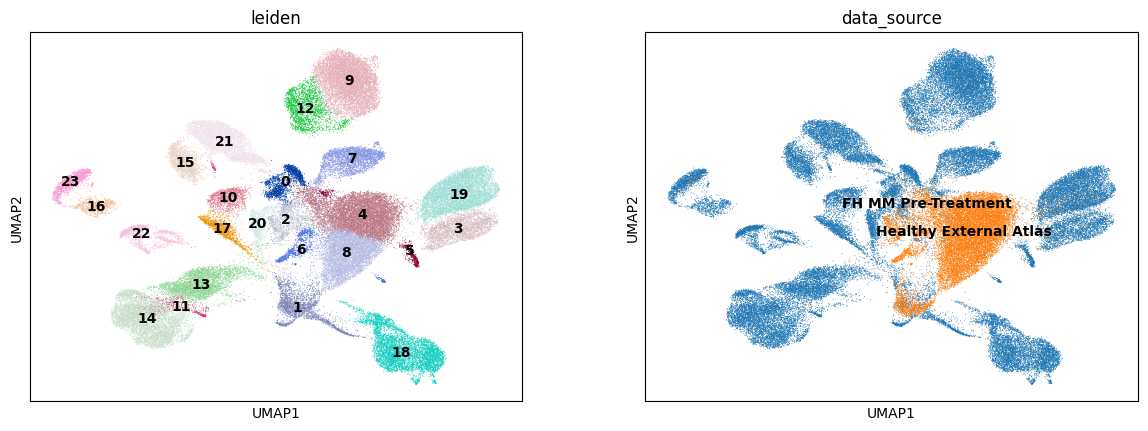

In [24]:
# view leiden clustering and color by data source to view how external healthy atlas plasma clusters
sc.pl.umap(adata, color = ['leiden', 'data_source'], legend_loc = "on data")

In [25]:
# write out final data object for input into inferCNV
adata.write("../../../data/rna/infercnv/pretx_and_healthy_plasma_chr_annotated_processed_harmony_20251010.h5ad")